## Model Development - Demo Version

In [77]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [78]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os
import io
from model import TabTransformer, ImprovedTabTransformer

## 1. Load data & Preprocessing

In [80]:
# --- 1. Load Data ---
## df = pd.read_excel("../data/data_demo.xlsx")
df_orig = pd.read_excel("../data/data_final_revision.xlsx")

In [81]:
df_orig.columns

Index(['url', 'filename', 'first_partner_gender', 'first_partner_age_bin',
       'second_partner_gender', 'second_partner_age_bin',
       'first_partner_school_category', 'second_partner_school_category',
       'first_partner_level_id', 'second_partner_level_id',
       'first_partner_field', 'second_partner_field', 'how_first_met_category',
       'first_partner_is_graduate', 'second_partner_is_graduate'],
      dtype='object')

## Encode categorical features

In [82]:
'''
this ensure that both first mentioned partner(male usually) and the second mentioned partner(female usually) are both used as the input and output, thus reduct traning df bais
''' 

df_A2B = df_orig.rename(columns={
    'first_partner_gender': 'partner_gender',
    'first_partner_age_bin': 'partner_age_bin',
    'first_partner_school_category': 'partner_school_category',
    'first_partner_level_id': 'partner_level_id',
    'first_partner_field': 'partner_field',
    'first_partner_is_graduate': 'partner_is_graduate',
    'second_partner_gender': 'target_gender',
    'second_partner_age_bin': 'target_age_bin',
    'second_partner_school_category': 'target_school_category',
    'second_partner_level_id': 'target_level_id',
    'second_partner_field': 'target_field'
})

df_B2A = df_orig.rename(columns={
    'second_partner_gender': 'partner_gender',
    'second_partner_age_bin': 'partner_age_bin',
    'second_partner_school_category': 'partner_school_category',
    'second_partner_level_id': 'partner_level_id',
    'second_partner_field': 'partner_field',
    'second_partner_is_graduate': 'partner_is_graduate',
    'first_partner_gender': 'target_gender',
    'first_partner_age_bin': 'target_age_bin',
    'first_partner_school_category': 'target_school_category',
    'first_partner_level_id': 'target_level_id',
    'first_partner_field': 'target_field'
})

df = pd.concat([df_A2B, df_B2A], ignore_index=True)

In [83]:
input_cols = ['partner_gender', 'partner_age_bin', 'partner_school_category',
              'partner_level_id', 'partner_field', 'partner_is_graduate']
output_cols = ['target_gender', 'target_age_bin', 'target_school_category',
               'target_level_id', 'target_field']
columns_to_encode = input_cols + output_cols

# Encode
label_encoders = {}
gender_classes = ['Male', 'Female', 'Nonbinary', 'Unknown']

# First create and fit a gender encoder
gender_le = LabelEncoder()
gender_le.fit(gender_classes)  # This is the critical step we were missing before

for col in columns_to_encode:
    df[col] = df[col].replace('Not mentioned', 'Unknown').astype(str).str.strip()
    
    if col in ['partner_gender', 'target_gender']:
        df[col] = df[col].apply(lambda x: x if x in gender_classes else 'Unknown')
        df[col] = gender_le.transform(df[col])
        label_encoders[col] = gender_le
    else:
        # Regular encoding for non-gender columns
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    
    # Check for class imbalance - now showing actual distribution
    class_counts = df[col].value_counts(normalize=True)
    print(f"\nClass distribution for {col}:")
    
    if col in ['partner_gender', 'target_gender']:
        # For gender columns, show human-readable labels
        for class_idx, percent in class_counts.items():
            print(f"  {gender_classes[class_idx]}: {percent*100:.1f}%")
    else:
        # For other columns, just show the encoded values
        print(class_counts.to_string())
    
    if len(class_counts) > 0 and class_counts.iloc[0] > 0.8:
        if col in ['partner_gender', 'target_gender']:
            dominant_class = gender_classes[class_counts.index[0]]
        else:
            dominant_class = class_counts.index[0]
        print(f"Warning: Dominant class '{dominant_class}' has {class_counts.iloc[0]*100:.1f}% of data")


Class distribution for partner_gender:
  Female: 47.0%
  Male: 45.8%
  Unknown: 7.1%
  Nonbinary: 0.0%

Class distribution for partner_age_bin:
partner_age_bin
1    0.395763
0    0.308726
2    0.127007
4    0.125478
3    0.043027

Class distribution for partner_school_category:
partner_school_category
2    0.452932
4    0.211368
0    0.205690
1    0.084799
3    0.045211

Class distribution for partner_level_id:
partner_level_id
3    0.405373
4    0.314841
2    0.155728
0    0.063886
6    0.037785
1    0.011467
5    0.010921

Class distribution for partner_field:
partner_field
3     0.286065
14    0.118980
12    0.099214
16    0.073659
18    0.070001
7     0.068527
1     0.055695
4     0.040297
26    0.037785
5     0.029977
0     0.027083
24    0.020749
15    0.019166
20    0.017855
8     0.014961
19    0.005570
11    0.003331
21    0.001857
23    0.001747
13    0.001474
6     0.001365
22    0.001256
25    0.000928
2     0.000819
17    0.000819
10    0.000601
9     0.000218

Class dist

## Split Data

In [84]:
# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    df[input_cols].values,
    df[output_cols].values,
    test_size=0.2, # 20% used for testing 
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [85]:
def augment_batch(batch_X, mask_prob=0.15, unknown_token=0):
    """Enhanced data augmentation with smarter masking"""
    # Create mask for random elements
    mask = torch.rand_like(batch_X.float()) < mask_prob
    
    # Create augmented batch by replacing masked elements with unknown token
    augmented = torch.where(mask, unknown_token * torch.ones_like(batch_X), batch_X)
    
    return augmented

## Train and test datasets

In [149]:
# initialize 
input_cardinality = [df[col].nunique() for col in input_cols]
output_cardinality = [df[col].nunique() for col in output_cols]

# model
model = ImprovedTabTransformer(
    category_sizes=input_cardinality,
    dim=64,  
    output_sizes=output_cardinality
)


In [150]:
# Train the model
from torch.optim import AdamW
criterions = [nn.CrossEntropyLoss() for _ in output_cols]
# optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer = optim.AdamW(model.parameters(), lr=0.001)


def augment_batch(batch_X, mask_prob=0.2):
    mask = torch.rand_like(batch_X.float()) < mask_prob
    # Replace with "unknown" token (assuming 0 is unused/unknown)
    return torch.where(mask, torch.zeros_like(batch_X), batch_X)


def train(model, X, Y, epochs=15, batch_size=64):
    model.train()
    for epoch in range(epochs):
        permutation = torch.randperm(X.size()[0])
        total_loss = 0

        for i in range(0, X.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_X, batch_Y = X[indices], Y[indices]
            batch_X = augment_batch(batch_X)

            optimizer.zero_grad()
            outputs = model(batch_X)

            losses = [
                criterions[j](outputs[j], batch_Y[:, j])
                for j in range(len(output_cols))
            ]
            loss = sum(losses)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f'Epoch {epoch+1}, Loss: {total_loss / len(X)}')
        
train(model, X_train, Y_train)

Epoch 1, Loss: 0.11282258371909433
Epoch 2, Loss: 0.10672820236860107
Epoch 3, Loss: 0.10567776747233518
Epoch 4, Loss: 0.1051383891713293
Epoch 5, Loss: 0.10484710122756068
Epoch 6, Loss: 0.10430695981135117
Epoch 7, Loss: 0.10399689133130978
Epoch 8, Loss: 0.10374650277584357
Epoch 9, Loss: 0.1034136636697687
Epoch 10, Loss: 0.10333808102580713
Epoch 11, Loss: 0.1031661455431584
Epoch 12, Loss: 0.10306000629795037
Epoch 13, Loss: 0.10295883320873568
Epoch 14, Loss: 0.10287482824254611
Epoch 15, Loss: 0.10283829947639493


In [151]:
# --- 8. Evaluation ---
def evaluate_average(model, X, Y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        correct = 0
        total = 0
        for j in range(len(output_cols)):
            _, predicted = torch.max(outputs[j].data, 1)
            correct += (predicted == Y[:, j]).sum().item()
            total += Y.size(0)
        accuracy = correct / total
        print(f'Accuracy: {accuracy:.4f}')

evaluate_average(model, X_test, Y_test)

Accuracy: 0.5595


In [152]:
def evaluate(model, X, Y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        total_acc = 0
        feature_acc = []

        for j in range(len(output_cols)):
            _, predicted = torch.max(outputs[j].data, 1)
            correct = (predicted == Y[:, j]).sum().item()
            acc = correct / Y.size(0)
            feature_acc.append(acc)
            total_acc += acc

        avg_acc = total_acc / len(output_cols)
        print(f'Average Accuracy: {avg_acc:.4f}')
        for col, acc in zip(output_cols, feature_acc):
            print(f'{col}: {acc:.4f}')

evaluate(model, X_test, Y_test)

Average Accuracy: 0.5595
target_gender: 0.8373
target_age_bin: 0.6312
target_school_category: 0.5138
target_level_id: 0.4611
target_field: 0.3544


In [153]:
from sklearn.metrics import classification_report

def detailed_evaluate(model, X, Y, label_encoders, output_path="evaluation_report.txt"):
    model.eval()
    report_output = io.StringIO()
    
    with torch.no_grad():
        outputs = model(X)
        
        for j, col in enumerate(output_cols):
            _, preds = torch.max(outputs[j], 1)
            true = Y[:, j]
            
            le = label_encoders[col]
            if col in ['target_gender', 'partner_gender']:
                target_names = gender_classes
            else:
                target_names = le.classes_

            report_output.write(f"\nEvaluation for {col}:\n")
            report_output.write(
                classification_report(
                    true.numpy(),
                    preds.numpy(),
                    target_names=target_names,
                    zero_division=0
                )
            )
    
    # Save to txt file
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(report_output.getvalue())

    print(f"Evaluation results saved to {output_path}")

detailed_evaluate(model, X_test, Y_test, label_encoders)

Evaluation results saved to evaluation_report.txt


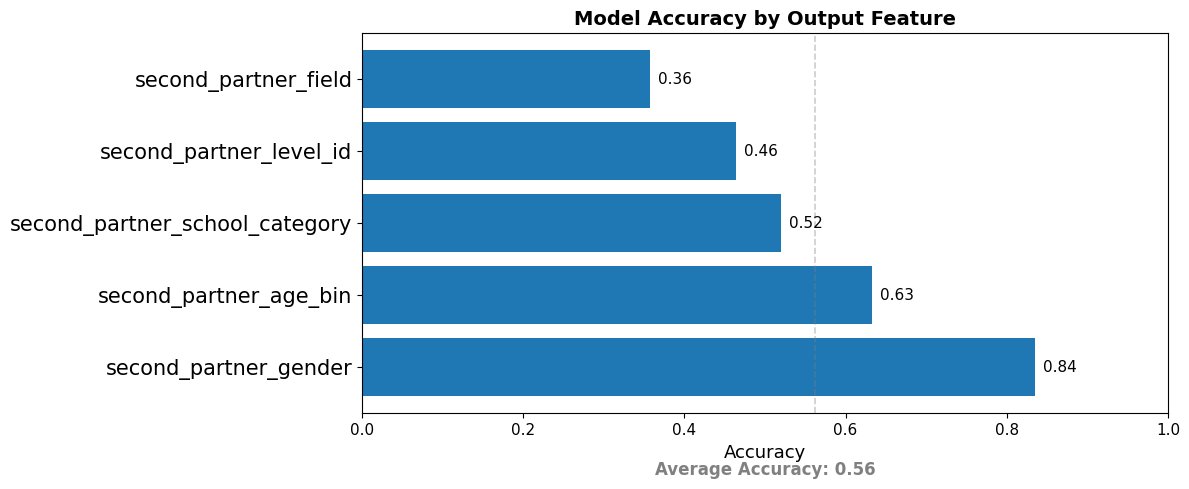

In [154]:
import matplotlib.pyplot as plt

output_fields = [
    "second_partner_gender",
    "second_partner_age_bin",
    "second_partner_school_category",
    "second_partner_level_id",
    "second_partner_field"
]
accuracies = [0.8351, 0.6323, 0.5198, 0.4644, 0.3568]
avg_accuracy = sum(accuracies) / len(accuracies)

plt.figure(figsize=(12, 5))
bars = plt.barh(output_fields, accuracies, color='#1f77b4')  
plt.xlabel("Accuracy", fontsize=13)
plt.title("Model Accuracy by Output Feature", fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=15)
plt.xlim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
             f"{acc:.2f}", va='center', fontsize=11)

plt.axvline(x=avg_accuracy, color='gray', linestyle='--', linewidth=1.2, alpha=0.4)

plt.text(0.5, -0.15, f"Average Accuracy: {avg_accuracy:.2f}",
         ha='center', va='center', transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', color='gray')

plt.tight_layout()
plt.show()

### Sample Test - The easiest one to goo...

In [128]:
def predict_partner(sample_row, model, label_encoders):
    """
    Predict partner attributes from a sample input row (6 features)

    Args:
        sample_row: List of [gender, age_bin, school_category, level_id, field, is_graduate]
        model: Trained TabTransformer model
        label_encoders: Dictionary of fitted LabelEncoders

    Returns:
        Dictionary of predicted attributes
    """
    # Ensure the model is in evaluation mode
    model.eval()

    # Step 1: Prepare input with all required features
    expected_len = 6
    if len(sample_row) != expected_len:
        raise ValueError(f"Input row must contain {expected_len} features: [gender, age_bin, school_category, level_id, field, is_graduate]")

    # Step 2: Define input column names (must match your training input_cols)
    input_cols = [
        'partner_gender',
        'partner_age_bin',
        'partner_school_category',
        'partner_level_id',
        'partner_field',
        'partner_is_graduate'
    ]

    # Step 3: Encode each feature using its LabelEncoder
    try:
        encoded_sample = []
        for col, value in zip(input_cols, sample_row):
            value_str = str(value).strip() if value is not None else 'Unknown'

            if value_str not in label_encoders[col].classes_:
                default_value = label_encoders[col].classes_[0]
                print(f"Warning: Unknown value '{value_str}' for {col}, using '{default_value}' instead")
                value_str = default_value

            encoded_val = label_encoders[col].transform([value_str])[0]
            encoded_sample.append(encoded_val)

    except Exception as e:
        print(f"Encoding error: {e}")
        return None

    # Step 4: Convert to tensor and add batch dimension
    import torch
    sample_tensor = torch.tensor([encoded_sample], dtype=torch.long)

    # Step 5: Get predictions from model
    with torch.no_grad():
        output_preds = model(sample_tensor)

    # Step 6: Decode model outputs
    output_cols = [
        'target_gender',
        'target_age_bin',
        'target_school_category',
        'target_level_id',
        'target_field'
    ]

    predictions = {}
    for i, col in enumerate(output_cols):
        pred_class = torch.argmax(output_preds[i], dim=1).item()
        predictions[col] = label_encoders[col].inverse_transform([pred_class])[0]

    return predictions

In [129]:
sample_row = [
    'Female',                       # partner_gender
    '30-34',                        # partner_age_bin
    'Ivy League',                   # partner_school_category
    'S4',                           # partner_level_id
    'Business and Financial Occupations',  # partner_field
    '1'                             # partner_is_graduate (as string to match encoder)
]

predictions = predict_partner(sample_row, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")



=== Predicted Partner Profile ===
Gender:         Male
Age Group:      30-34
School Category: Other Colleges
Education Level: S5
Field of Study:  Business and Financial Occupations


In [130]:
sample_row_2 = [
    'Male',
    '25-29',
    'Top 50 Private (Non-Ivy)',
    'S3',
    'Architecture and Engineering Occupations',
    '0'  # not graduate
]

predictions = predict_partner(sample_row_2, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Female
Age Group:      25-29
School Category: Top 50 Private (Non-Ivy)
Education Level: S4
Field of Study:  Business and Financial Occupations


In [131]:
sample_row_3 = [
    'Female',
    '35-39',
    'Top 50 Private (Non-Ivy)',
    'S5',
    'Arts and Design Occupations',
    '1'
]

predictions = predict_partner(sample_row_3, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Male
Age Group:      35-39
School Category: Other Colleges
Education Level: S5
Field of Study:  Business and Financial Occupations


In [132]:
sample_row_4 = [
    'Nonbinary',
    '30-34',
    'Other Colleges',
    'S5',
    'Media and Communication Occupations',
    '1'
]

predictions = predict_partner(sample_row_4, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Female
Age Group:      30-34
School Category: Other Colleges
Education Level: S5
Field of Study:  Media and Communication Occupations


## Baseline Model

- TODO (?): Compare with a simple MLP
- More for report purpose
  


In [155]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter

# 1. Define the baseline MLP
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_sizes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.output_heads = nn.ModuleList([
            nn.Linear(hidden_dim, out_size) for out_size in output_sizes
        ])

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return [head(x) for head in self.output_heads]

# 2. Helper for class weights
def compute_class_weights(y_col, num_classes):
    counts = Counter(y_col.tolist())
    total = sum(counts.values())
    weights = [total / (counts.get(i, 1)) for i in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float32)

# 3. Augment batch by masking
def augment_batch(batch_X, mask_prob=0.2):
    mask = torch.rand_like(batch_X.float()) < mask_prob
    return torch.where(mask, torch.zeros_like(batch_X), batch_X)

# 4. Training function
def train(model, X, Y, epochs=15, batch_size=64):
    model.train()
    for epoch in range(epochs):
        permutation = torch.randperm(X.size(0))
        total_loss = 0

        for i in range(0, X.size(0), batch_size):
            indices = permutation[i:i+batch_size]
            batch_X, batch_Y = X[indices].to(device).float(), Y[indices].to(device)

            batch_X = augment_batch(batch_X)

            optimizer.zero_grad()
            outputs = model(batch_X)

            losses = [
                criterions[j](outputs[j], batch_Y[:, j])
                for j in range(len(output_cols))
            ]
            loss = sum(losses)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f'Epoch {epoch+1}, Loss: {total_loss / len(X):.4f}')

# 5. Evaluation function
def evaluate(model, X, Y):
    model.eval()
    with torch.no_grad():
        X = X.to(device).float()
        Y = Y.to(device)
        outputs = model(X)
        total_acc = 0
        feature_acc = []

        for j in range(len(output_cols)):
            _, predicted = torch.max(outputs[j].data, 1)
            correct = (predicted == Y[:, j]).sum().item()
            acc = correct / Y.size(0)
            feature_acc.append(acc)
            total_acc += acc

        avg_acc = total_acc / len(output_cols)
        print(f'\nAverage Accuracy: {avg_acc:.4f}')
        for col, acc in zip(output_cols, feature_acc):
            print(f'{col}: {acc:.4f}')

# 6. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train.shape[1]
output_sizes = [len(label_encoders[col].classes_) for col in output_cols]

baseline_model = BaselineMLP(input_dim=input_dim, hidden_dim=128, output_sizes=output_sizes).to(device)

# 7. Loss functions (weighted cross-entropy)
criterions = []
for j, col in enumerate(output_cols):
    y_col = Y_train[:, j]
    num_classes = len(label_encoders[col].classes_)
    class_weights = compute_class_weights(y_col, num_classes).to(device)
    criterions.append(nn.CrossEntropyLoss(weight=class_weights))

# 8. Optimizer
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

# 9. Train & Evaluate
train(baseline_model, X_train, Y_train)
evaluate(baseline_model, X_test, Y_test)


Epoch 1, Loss: 0.1455
Epoch 2, Loss: 0.1408
Epoch 3, Loss: 0.1392
Epoch 4, Loss: 0.1377
Epoch 5, Loss: 0.1363
Epoch 6, Loss: 0.1360
Epoch 7, Loss: 0.1351
Epoch 8, Loss: 0.1343
Epoch 9, Loss: 0.1343
Epoch 10, Loss: 0.1339
Epoch 11, Loss: 0.1337
Epoch 12, Loss: 0.1333
Epoch 13, Loss: 0.1325
Epoch 14, Loss: 0.1325
Epoch 15, Loss: 0.1330

Average Accuracy: 0.4478
target_gender: 0.7871
target_age_bin: 0.5924
target_school_category: 0.3571
target_level_id: 0.3107
target_field: 0.1919
